In [8]:
import os
import sys
import gdstk
import numpy as np
import matplotlib.pyplot as plt

# Add current directory to path to import the generator
sys.path.append(os.getcwd())

from quantum_dot_pad_generator_18dot_v4 import QuantumDotPadGenerator18DotV4

%matplotlib inline


In [9]:
# 1. Initialize the generator
generator = QuantumDotPadGenerator18DotV4()

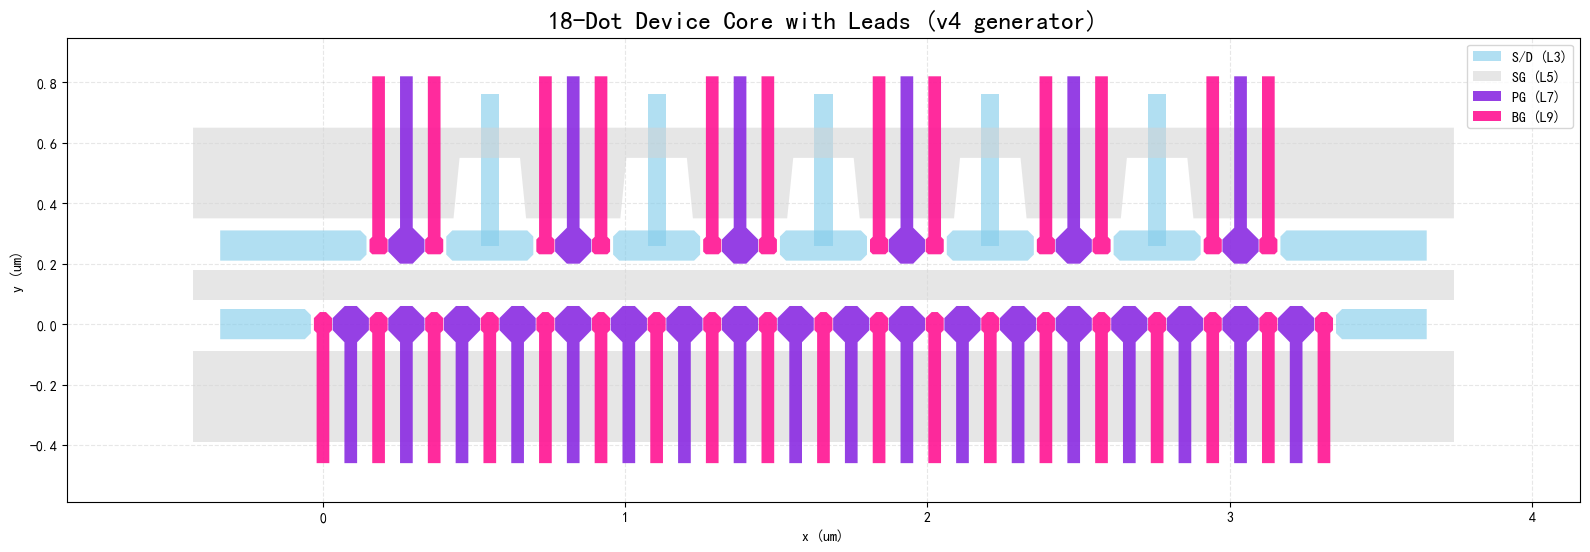

In [10]:
# 2. Generate the 18-dot device layout
device_lib, device_cell, device_connection_points, sg_width = generator.generate_quantum_dot_layout(
    sg_extension=0.4
)

# Visualize the device core
generator._plot_gds(device_cell, title="18-Dot Device Core with Leads (v4 generator)")


--- 18-Dot Pad Frame with Four Active Regions (v4) ---
正在可视化: 18-Dot Pad Frame with Four Active Regions (v4)...


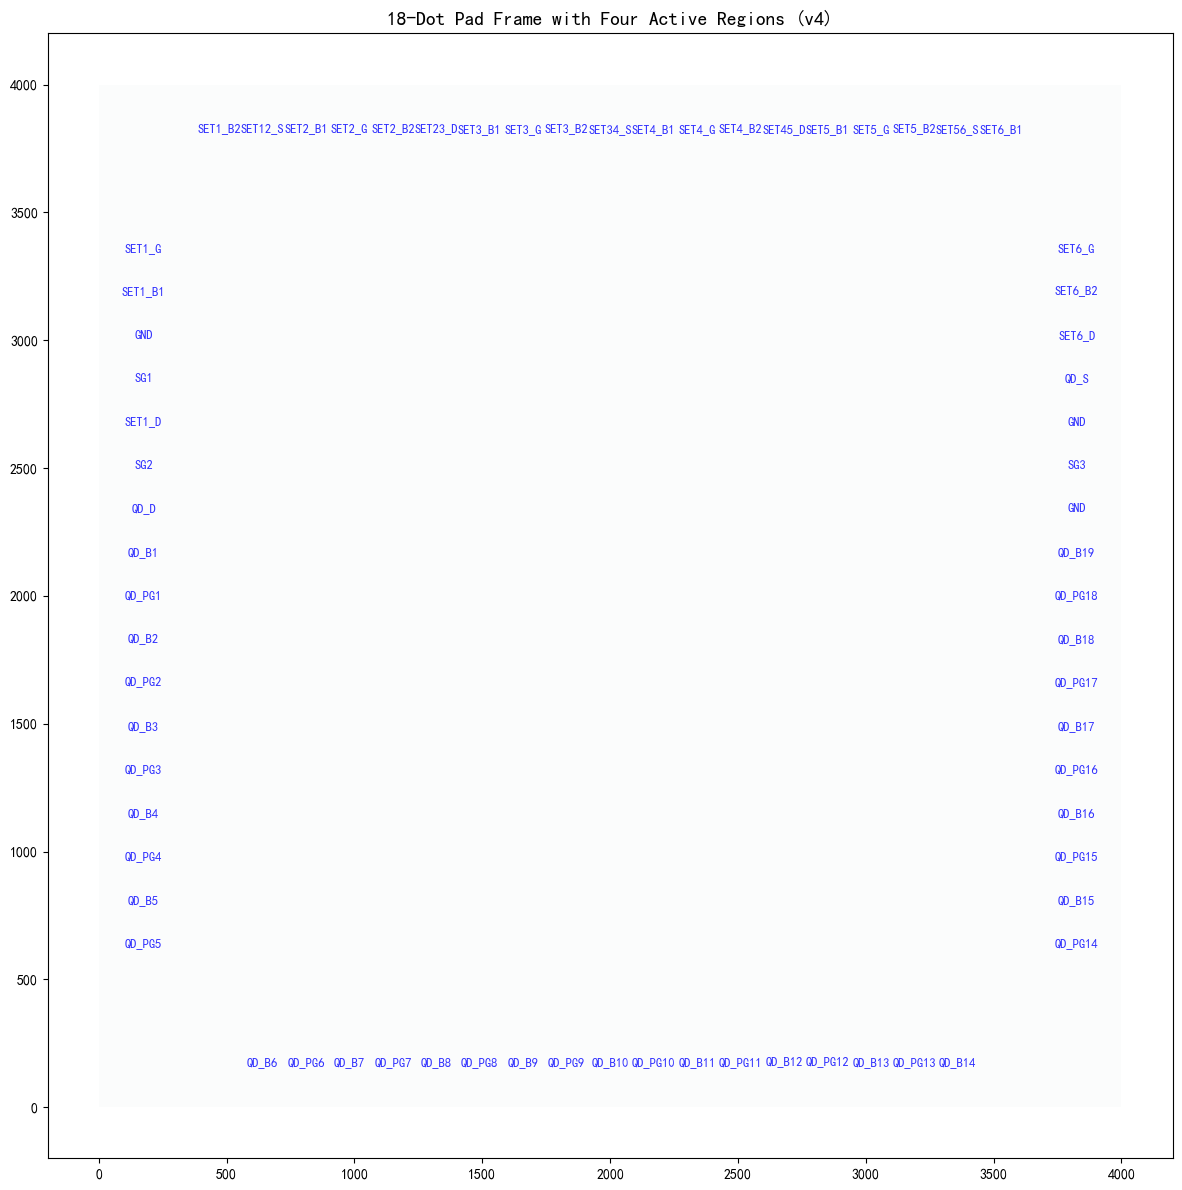

GDS 文件已保存到: '18dot_pad_frame_v3.gds'



In [11]:
# 3. Generate the pad frame layout with four active regions
pad_lib, pad_cell, pad_connection_points, active_center, all_pads_info = generator.generate_pad_frame_layout(
    layout_width=4000,
    layout_height=4000,
    taper_length=40,
    pad_width=100,
    pad_height=150,
    pad_spacing=70,
    
    active_width=750,
    active_height=600,
    trace_width=10,
    trace_spacing=17,
    
    active_size_2=400,
    inner_trace_width=6,
    inner_trace_spacing=14,
    active_entry_len_2=15,
    
    active_size_3=70,
    inner_trace_width_3=1,
    inner_trace_spacing_3=2,
    active_entry_len_3=8,
    
    active_width_4=15,
    active_height_4=13,
    inner_trace_width_4=0.15,
    inner_trace_spacing_4=0.2,
    active_entry_len_4=1
)

# Visualize and save the pad frame
generator.visualize_and_save_pad_frame(
    pad_lib,
    pad_cell,
    "18-Dot Pad Frame with Four Active Regions (v4)",
    "18dot_pad_frame_v3.gds"
)


--- 18-Dot Full Assembly v3 ---
正在可视化: 18-Dot Full Assembly v3...
GDS 文件已保存到: '18dot_full_assembly_v3.gds'


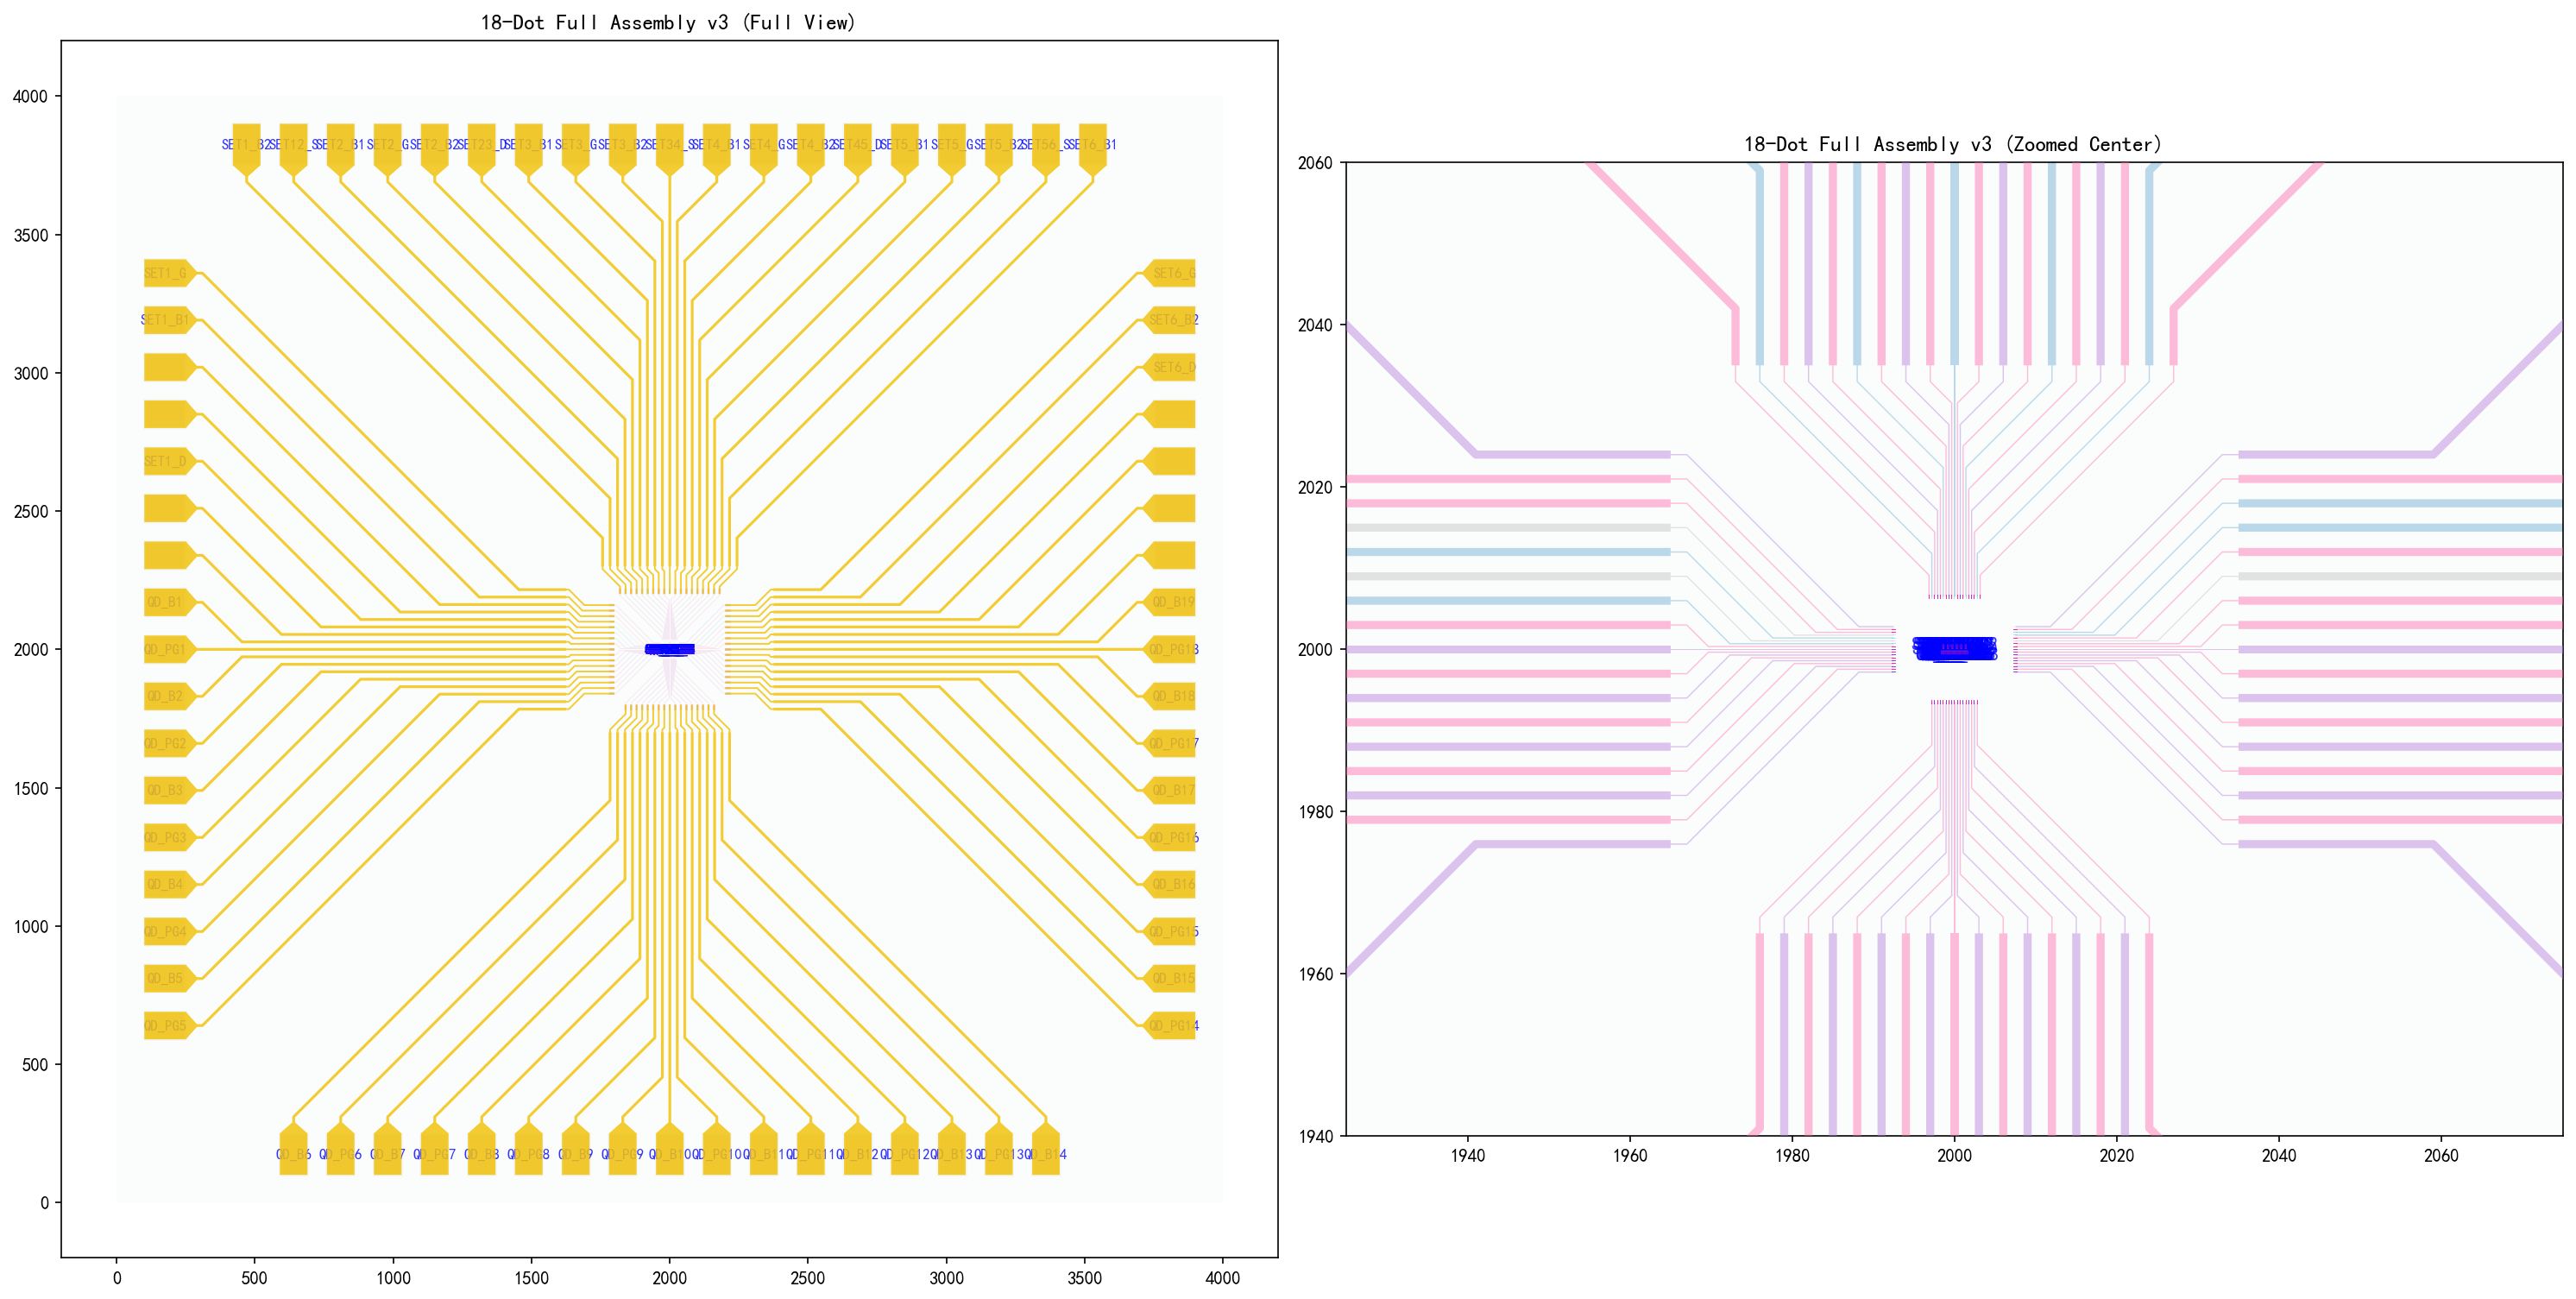

Successfully assembled and saved 18dot_full_assembly_v3.gds


In [12]:
# 4. Assemble the device and the pad frame
assembly_lib1, assembly_cell1 = generator.assemble_device_and_pad_frame()

if assembly_cell1 is not None:
    generator.visualize_and_save_assembly(
        assembly_lib1,
        assembly_cell1,
        "18-Dot Full Assembly v3",
        "18dot_full_assembly_v3.gds"
    )
    print("Successfully assembled and saved 18dot_full_assembly_v3.gds")
else:
    print("Error: Assembly failed.")


Connecting bottom pad leads...
Connecting right pad leads...
Connecting left pad leads...
Connecting SG3 pad lead...
Connecting QD_S pad lead...
Connecting SET6_D pad lead...
Connecting left pad leads...
Connecting QD_D pad lead...
Connecting SG2 pad lead...
Connecting SET1_D pad lead...
Connecting SG1 pad lead...
Connecting top pad leads...
--- 18-Dot Full Assembly v3 with Wires ---
正在可视化: 18-Dot Full Assembly v3 with Wires...
GDS 文件已保存到: '18dot_full_assembly_v3_wired.gds'


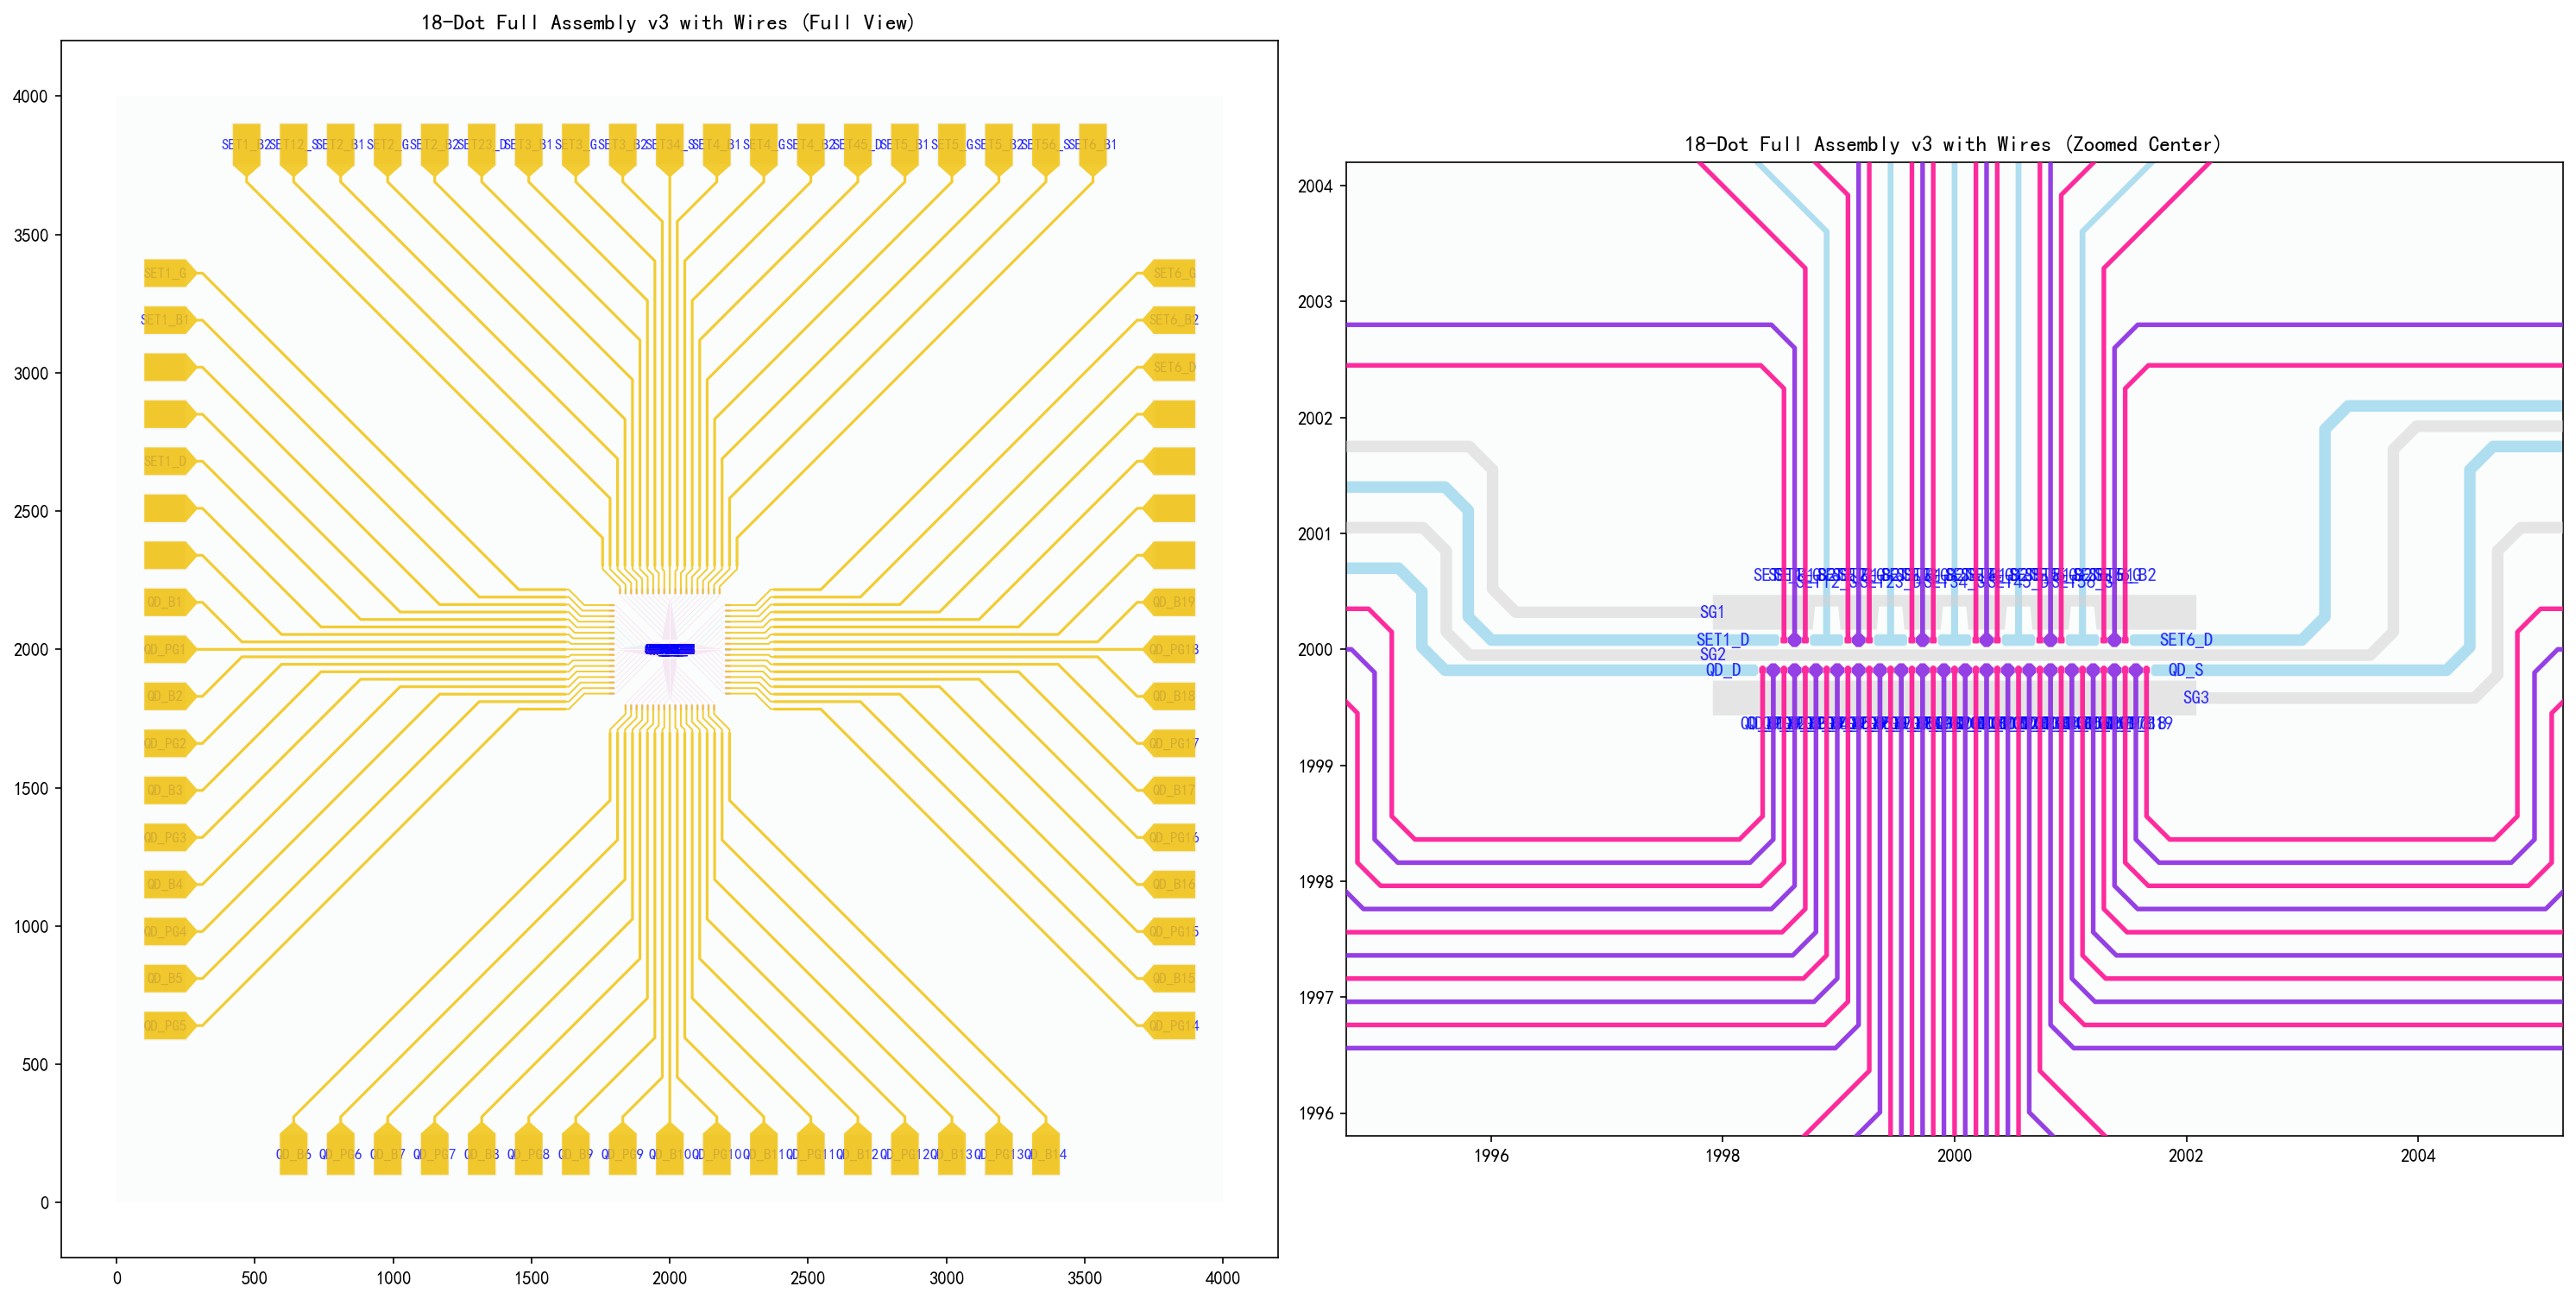


Successfully assembled, wired, and saved 18dot_full_assembly_v3_wired.gds
--- 18-Dot Full Assembly v3 with Wires ---
正在可视化: 18-Dot Full Assembly v3 with Wires...
GDS 文件已保存到: 'Z:\GDS Design\18dot\20260325 18dot_full_assembly_v3_wired.gds'


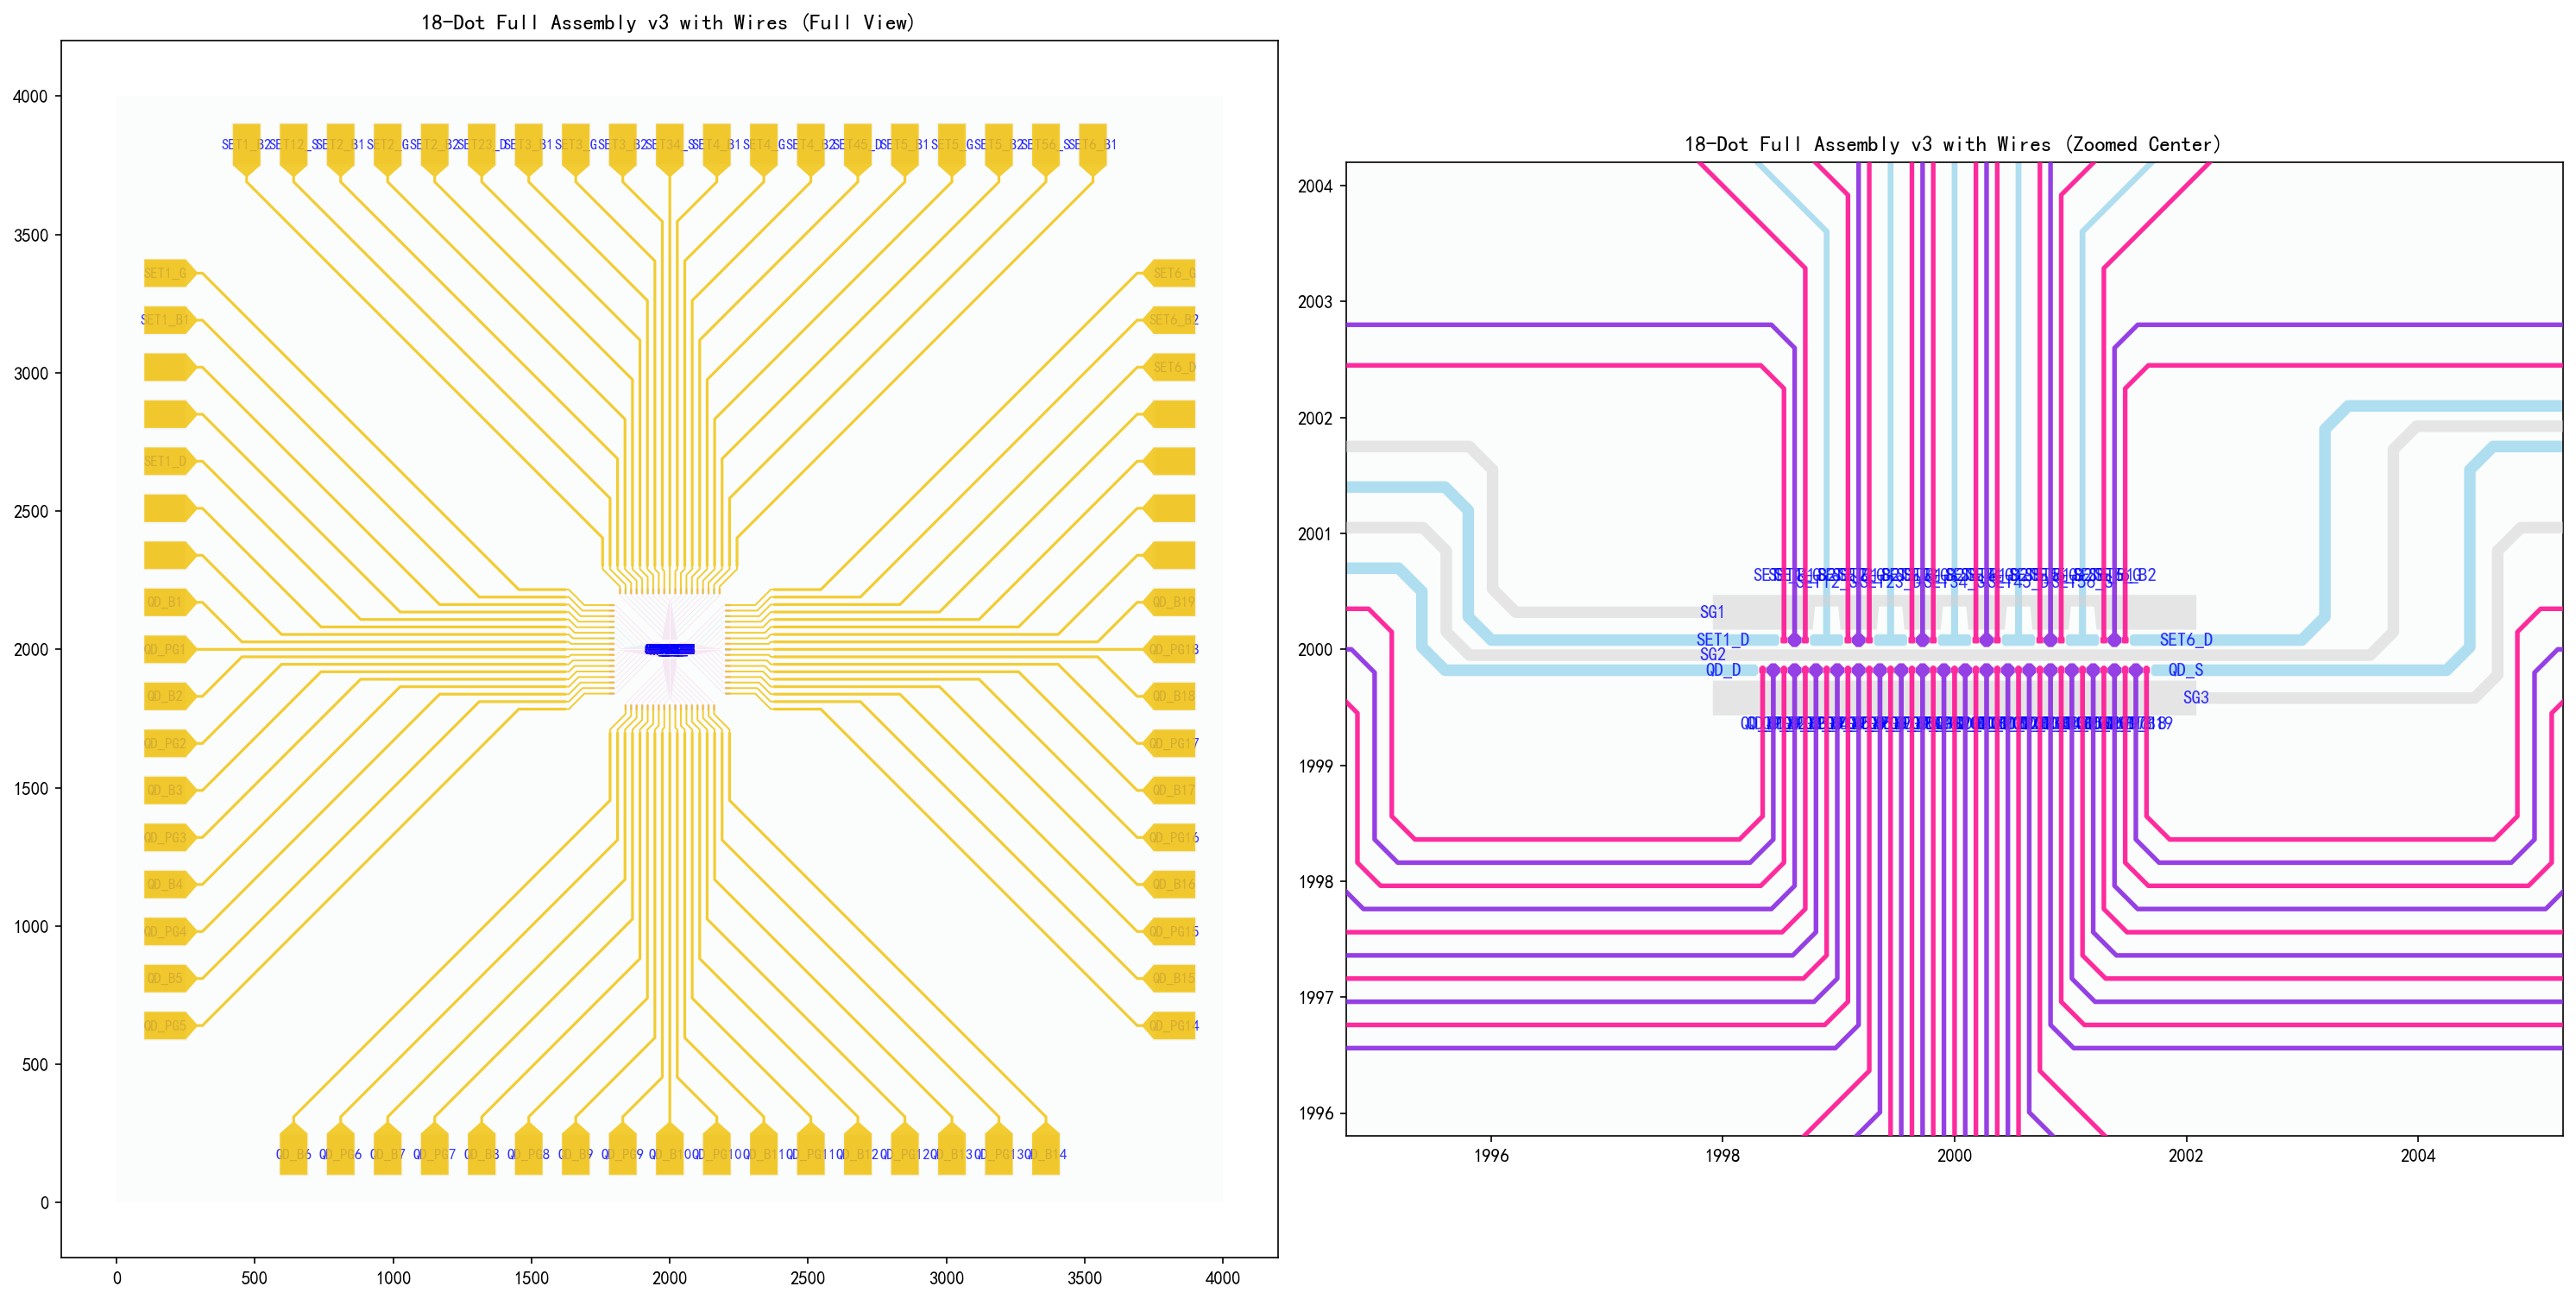


Successfully assembled, wired, and saved 18dot_full_assembly_v3_wired.gds in the folder Z:\GDS Design\18dot\ 


In [13]:
# 5. Add connection wires one by one
assembly_lib2, assembly_cell2 = generator.assemble_device_and_pad_frame()

LAYER_SD = 3
LAYER_SG = 5
LAYER_PG = 7
LAYER_BG = 9

def get_wire_layer(label):
    if "_PG" in label:
        return LAYER_PG
    if "SG" in label:
        return LAYER_SG
    if "_D" in label:
        return LAYER_SD
    if "_S" in label:
        return LAYER_SD
    if "_G" in label:
        return LAYER_PG
    if "_B" in label:
        return LAYER_BG
    return LAYER_SD


if assembly_cell2 is not None:
    import pandas as pd
    from IPython.display import display

    bbox = device_cell.bounding_box()
    dev_cx, dev_cy = (bbox[0][0] + bbox[1][0]) / 2, (bbox[0][1] + bbox[1][1]) / 2
    tx, ty = active_center[0] - dev_cx, active_center[1] - dev_cy

    # 1. Connect Bottom QD leads (QD_B6 ~ QD_B14)
    bottom_labels = ["QD_B6", "QD_PG6", "QD_B7", "QD_PG7", "QD_B8", "QD_PG8", "QD_B9", "QD_PG9", "QD_B10", "QD_PG10", "QD_B11", "QD_PG11", "QD_B12", "QD_PG12", "QD_B13", "QD_PG13", "QD_B14"]
    print("Connecting bottom pad leads...")
    for i, label in enumerate(bottom_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            if label == "QD_B10":
                path_pts = [p_pad, p_dev]
            else:
                dist_from_center = abs(i - 8)
                entry_length = 0.1 * dist_from_center
                delta_x = p_dev[0] - p_pad[0]
                p_turn_pad = (p_pad[0], p_pad[1] + entry_length)
                p_turn_dev = (p_dev[0], p_pad[1] + entry_length + abs(delta_x))
                path_pts = [p_pad, p_turn_pad, p_turn_dev, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040, layer=get_wire_layer(label))
            assembly_cell2.add(wire)

    # 2. Connect Right QD leads (QD_PG14 ~ QD_B19)
    QD_right_labels = ["QD_PG14", "QD_B15", "QD_PG15", "QD_B16", "QD_PG16", "QD_B17", "QD_PG17", "QD_B18", "QD_PG18", "QD_B19"]
    print("Connecting right pad leads...")
    for i, label in enumerate(QD_right_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            delta_y = p_pad[1] - p_dev[1]
            dev_entry = 0.8 + 0.2 * abs(9 - i)
            bend = 0.2
            extend = 3 + 0.24 * abs(9 - i)
            pt1 = (p_dev[0], p_dev[1] - dev_entry)
            pt2 = (p_dev[0] + bend, p_dev[1] - dev_entry - bend)
            pt3 = (p_dev[0] + extend, p_dev[1] - dev_entry - bend)
            pt4 = (p_dev[0] + extend + bend, p_dev[1] - dev_entry)
            pt5 = (p_dev[0] + extend + bend, p_dev[1] + delta_y - bend)
            pt6 = (p_dev[0] + extend + bend * 2, p_dev[1] + delta_y)
            path_pts = [p_pad, pt6, pt5, pt4, pt3, pt2, pt1, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040, layer=get_wire_layer(label))
            assembly_cell2.add(wire)

    # 3. Connect Left QD leads (QD_B1 ~ QD_PG5)
    QD_left_labels = ["QD_B1", "QD_PG1", "QD_B2", "QD_PG2", "QD_B3", "QD_PG3", "QD_B4", "QD_PG4", "QD_B5", "QD_PG5"]
    print("Connecting left pad leads...")
    for i, label in enumerate(QD_left_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            delta_y = p_pad[1] - p_dev[1]
            dev_entry = 0.8 + 0.2 * abs(i)
            bend = 0.2
            extend = 3 + 0.24 * abs(i)
            pt1 = (p_dev[0], p_dev[1] - dev_entry)
            pt2 = (p_dev[0] - bend, p_dev[1] - dev_entry - bend)
            pt3 = (p_dev[0] - extend, p_dev[1] - dev_entry - bend)
            pt4 = (p_dev[0] - extend - bend, p_dev[1] - dev_entry)
            pt5 = (p_dev[0] - extend - bend, p_dev[1] + delta_y - bend)
            pt6 = (p_dev[0] - extend - bend * 2, p_dev[1] + delta_y)
            path_pts = [p_pad, pt6, pt5, pt4, pt3, pt2, pt1, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040, layer=get_wire_layer(label))
            assembly_cell2.add(wire)

    # left side special leads
    label = "SG3"
    print("Connecting SG3 pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        bend = 0.2
        extend = 2.4
        pt1 = (p_dev[0] + extend, p_dev[1])
        pt2 = (p_dev[0] + extend + bend, p_dev[1] + bend)
        pt3 = (p_dev[0] + extend + bend, p_pad[1] - bend)
        pt4 = (p_dev[0] + extend + bend * 2, p_pad[1])
        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.10, layer=get_wire_layer(label))
        assembly_cell2.add(wire)

    label = "QD_S"
    print("Connecting QD_S pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        bend = 0.2
        extend = 2.25
        pt1 = (p_dev[0] + extend, p_dev[1])
        pt2 = (p_dev[0] + extend + bend, p_dev[1] + bend)
        pt3 = (p_dev[0] + extend + bend, p_pad[1] - bend)
        pt4 = (p_dev[0] + extend + bend * 2, p_pad[1])
        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1, layer=get_wire_layer(label))
        assembly_cell2.add(wire)

    label = "SET6_D"
    print("Connecting SET6_D pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        bend = 0.2
        extend = 1.0
        pt1 = (p_dev[0] + extend, p_dev[1])
        pt2 = (p_dev[0] + extend + bend, p_dev[1] + bend)
        pt3 = (p_dev[0] + extend + bend, p_pad[1] - bend)
        pt4 = (p_dev[0] + extend + bend * 2, p_pad[1])
        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1, layer=get_wire_layer(label))
        assembly_cell2.add(wire)

    SET_left_labels = ["SET1_B1", "SET1_G"]
    print("Connecting left pad leads...")
    for i, label in enumerate(SET_left_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            bend = 0.2
            pt1 = (p_dev[0], p_pad[1] - bend)
            pt2 = (p_dev[0] - bend, p_pad[1])
            path_pts = [p_pad, pt2, pt1, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040, layer=get_wire_layer(label))
            assembly_cell2.add(wire)

    SET_right_labels = ["SET6_B2", "SET6_G"]
    for i, label in enumerate(SET_right_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            bend = 0.2
            pt1 = (p_dev[0], p_pad[1] - bend)
            pt2 = (p_dev[0] + bend, p_pad[1])
            path_pts = [p_pad, pt2, pt1, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040, layer=get_wire_layer(label))
            assembly_cell2.add(wire)

    label = "QD_D"
    print("Connecting QD_D pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        bend = 0.2
        extend = 2.4
        pt1 = (p_dev[0] - extend, p_dev[1])
        pt2 = (p_dev[0] - extend - bend, p_dev[1] + bend)
        pt3 = (p_dev[0] - extend - bend, p_pad[1] - bend)
        pt4 = (p_dev[0] - extend - bend * 2, p_pad[1])
        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1, layer=get_wire_layer(label))
        assembly_cell2.add(wire)

    label = "SG2"
    print("Connecting SG2 pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        bend = 0.2
        extend = 2.1
        pt1 = (p_dev[0] - extend, p_dev[1])
        pt2 = (p_dev[0] - extend - bend, p_dev[1] + bend)
        pt3 = (p_dev[0] - extend - bend, p_pad[1] - bend)
        pt4 = (p_dev[0] - extend - bend * 2, p_pad[1])
        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1, layer=get_wire_layer(label))
        assembly_cell2.add(wire)

        SG2_right_x = p_dev[0] + sg_width
        extend_right = 1.5
        p_dev_right = (SG2_right_x, p_dev[1])
        p_pad_upper = (
            (pad_connection_points["SET6_D"][0] + pad_connection_points["QD_S"][0]) / 2,
            (pad_connection_points["SET6_D"][1] + pad_connection_points["QD_S"][1]) / 2
        )

        pt1 = (p_dev_right[0] + extend_right, p_dev_right[1])
        pt2 = (p_dev_right[0] + extend_right + bend, p_dev_right[1] + bend)
        pt3 = (p_dev_right[0] + extend_right + bend, p_pad_upper[1] - bend)
        pt4 = (p_dev_right[0] + extend_right + bend*2, p_pad_upper[1])
        pt5 = (p_pad_upper[0] - 1, p_pad_upper[1])
        path_pts = [pt5, pt4, pt3, pt2, pt1, p_dev_right]
        wire2 = generator.create_gds_wire(path_pts, width=0.1, layer=get_wire_layer(label))
        assembly_cell2.add(wire2)

    label = "SET1_D"
    print("Connecting SET1_D pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        bend = 0.2
        extend = 2.0
        pt1 = (p_dev[0] - extend, p_dev[1])
        pt2 = (p_dev[0] - extend - bend, p_dev[1] + bend)
        pt3 = (p_dev[0] - extend - bend, p_pad[1] - bend)
        pt4 = (p_dev[0] - extend - bend * 2, p_pad[1])
        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1, layer=get_wire_layer(label))
        assembly_cell2.add(wire)

        

    label = "SG1"
    print("Connecting SG1 pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        bend = 0.2
        extend = 1.7
        pt1 = (p_dev[0] - extend, p_dev[1])
        pt2 = (p_dev[0] - extend - bend, p_dev[1] + bend)
        pt3 = (p_dev[0] - extend - bend, p_pad[1] - bend)
        pt4 = (p_dev[0] - extend - bend * 2, p_pad[1])
        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1, layer=get_wire_layer(label))
        assembly_cell2.add(wire)

    top_labels = ["SET1_B2", "SET12_S", "SET2_B1", "SET2_G", "SET2_B2", "SET23_D", "SET3_B1", "SET3_G", "SET3_B2", 
                  "SET34_S", 
                  "SET4_B1", "SET4_G", "SET4_B2", "SET45_D", "SET5_B1", "SET5_G", "SET5_B2", "SET56_S", "SET6_B1"]
    print("Connecting top pad leads...")
    for i, label in enumerate(top_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            if label == "SET34_S":
                path_pts = [p_pad, p_dev]
            else:
                dist_from_center = abs(i - 9)
                entry_length = 0.15 * dist_from_center
                delta_x = p_dev[0] - p_pad[0]
                p_turn_pad = (p_pad[0], p_pad[1] - entry_length)
                p_turn_dev = (p_dev[0], p_pad[1] - entry_length - abs(delta_x))
                path_pts = [p_pad, p_turn_pad, p_turn_dev, p_dev]
            width = 0.050 if "_S" in label or "_D" in label else 0.040
            wire = generator.create_gds_wire(path_pts, width=width, layer=get_wire_layer(label))
            assembly_cell2.add(wire)

    generator.visualize_and_save_assembly(
        assembly_lib2,
        assembly_cell2,
        "18-Dot Full Assembly v3 with Wires",
        "18dot_full_assembly_v3_wired.gds",
        zoom_factor=0.007
    )

    print("\nSuccessfully assembled, wired, and saved 18dot_full_assembly_v3_wired.gds")

    generator.visualize_and_save_assembly(
        assembly_lib2,
        assembly_cell2,
        "18-Dot Full Assembly v3 with Wires",
        "Z:\\GDS Design\\18dot\\20260325 18dot_full_assembly_v3_wired.gds",
        zoom_factor=0.007
    )

    print("\nSuccessfully assembled, wired, and saved 18dot_full_assembly_v3_wired.gds in the folder Z:\\GDS Design\\18dot\\ ")
else:
    print("Error: Assembly failed.")


In [14]:
print(generator.qd_params['sg_extension'])

0.4
